In [1]:
%load_ext autoreload
%autoreload 2
import sys

if ".." not in sys.path:
    sys.path.append("../../../..")

import numpy as np
import importlib

importlib.reload(mmd)

from sklearn_extra.cluster import KMedoids
from scipy.spatial.distance import pdist, squareform
from signature.learning.MMD import kmeans_customized, mmd as mmd

from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt


# distances

def mmd_distance(X, Y):
    return mmd.MMD(X, Y, bias=True)


def mmd_distance_euclidean(X, Y):
    return mmd.MMD_sig_euclidean(X, Y, bias=True)


def mmd_pathwise_windows(X, Y):
    return mmd.MMD_one_realization(X, Y)


#  K means of sklearn with kustomized distance matrix


def kmeans_mmd(X, k, metric=mmd_distance_euclidean):
    """
    KMedoids clustering con distanza personalizzata
    X: array-like dei dati (n_samples iid, n_features)
    k: numero di cluster
    metric: può essere una stringa (es. 'euclidean', 'manhattan')
            oppure una funzione custom(a,b) -> float
    """

    # Se metric è una funzione, calcoliamo la matrice di distanze precompute
    if callable(metric):
        dist_matrix = squareform(pdist(X, metric=metric))
        kmedoids = KMedoids(n_clusters=k, metric='precomputed', random_state=0)
        kmedoids.fit(dist_matrix)
    else:
        # metric è una stringa standard
        kmedoids = KMedoids(n_clusters=k, metric=metric, random_state=0)
        kmedoids.fit(X)

    return kmedoids.labels_


In [45]:
# %%


np.random.seed(42)

M = 30
T = 2000
sigma1 = 0.2
sigma2 = 0.4
sigma3 = 0.6
sigma4 = 0.25 # 2

increments1 = np.random.normal(0, 1, size=(T, M))
increments2 = np.random.normal(0, 1, size=(T, M))
increments3 = np.random.normal(0, 1, size=(T, M))
increments4 = np.random.normal(0, 1, size=(T, M))

S1 = sigma1 * np.cumsum(increments1, axis=0).T
S2 = sigma2 * np.cumsum(increments2, axis=0).T
S3 = sigma3 * np.cumsum(increments3, axis=0).T
S4 = sigma4 * np.cumsum(increments4, axis=0).T

# True labels
labels_S1 = np.ones((S1.shape[0], 1))
labels_S2 = np.ones((S2.shape[0], 1)) * 2
labels_S3 = np.ones((S3.shape[0], 1)) * 3
labels_S4 = np.ones((S4.shape[0], 1)) * 4

S = np.vstack((S1, S4))
labels = np.vstack((labels_S1 * 0, labels_S4 / 4))

print("labels shape:", labels.shape)
print("paths shape:", S.shape)


labels shape: (60, 1)
paths shape: (60, 2000)


Distance matrix:
 [[0.00000000e+00 1.60192530e+05 4.74040000e+03 ... 1.03700000e+01
  1.42173258e+06 1.00000000e-02]
 [1.60192530e+05 0.00000000e+00 1.33902590e+05 ... 1.59242600e+05
  6.32464040e+05 1.60192840e+05]
 [4.74040000e+03 1.33902590e+05 0.00000000e+00 ... 4.74311000e+03
  1.32413987e+06 4.74413000e+03]
 ...
 [1.03700000e+01 1.59242600e+05 4.74311000e+03 ... 0.00000000e+00
  1.41934083e+06 1.00500000e+01]
 [1.42173258e+06 6.32464040e+05 1.32413987e+06 ... 1.41934083e+06
  0.00000000e+00 1.42173384e+06]
 [1.00000000e-02 1.60192840e+05 4.74413000e+03 ... 1.00500000e+01
  1.42173384e+06 0.00000000e+00]]
Silhouette score pathwise is 0.29819385539270926
Standard Accuracy k_means with MMD pathwise distance: 0.5
Confusion Matrix pathwise:
 [[ 5 25]
 [ 5 25]]
Clustering Accuracy with Hungarian algorithm pathwise: 0.5


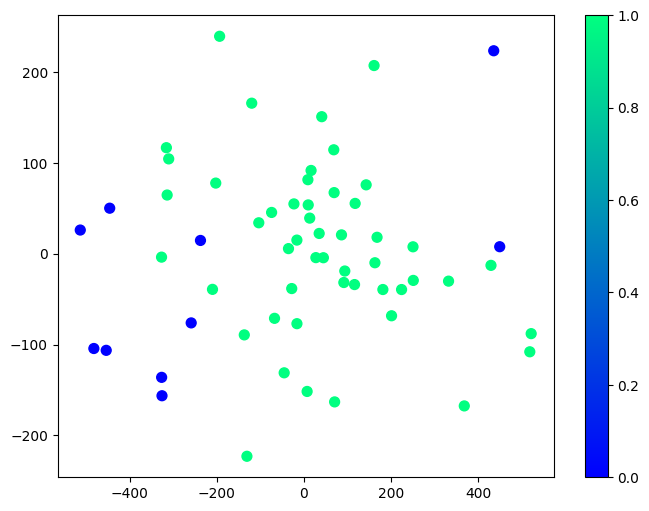

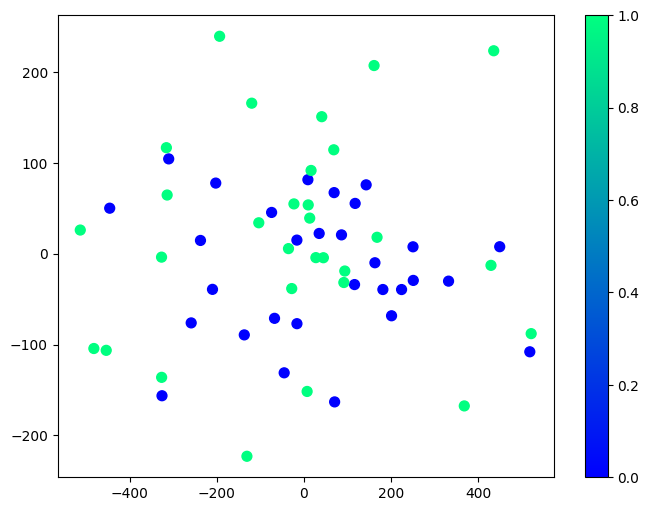

In [46]:

# Clustering K-Means with MMD pathwise

computed_labels_pathwise = kmeans_customized.kmeans_mmd(S, 2, metric=kmeans_customized.mmd_distance_euclidean)

score_pathwise = silhouette_score(S, computed_labels_pathwise)
print(f"Silhouette score pathwise is {score_pathwise}")

accuracy_pathwise = np.mean(np.abs(computed_labels_pathwise == labels))
print("Standard Accuracy k_means with MMD pathwise distance:", accuracy_pathwise)

#Compute accuracy with Hungarian algorithm

# 1 Create confusion matrix
conf_mat = confusion_matrix(labels, computed_labels_pathwise)
print("Confusion Matrix pathwise:\n", conf_mat)

# 2 Convert to cost matrix (Hungarian algorithm minimizes cost,
# so we subtract from max to maximize correct matches)
cost_matrix = conf_mat.max() - conf_mat

#  3 Apply Hungarian algorithm to find optimal assignment
row_ind, col_ind = linear_sum_assignment(cost_matrix)

# 4️ Calculate clustering accuracy
total_correct = conf_mat[row_ind, col_ind].sum()
accuracy = total_correct / conf_mat.sum()

print("Clustering Accuracy with Hungarian algorithm pathwise:", accuracy)

#PCA for visualization ?

pca = PCA(n_components=2)
X_pca = pca.fit_transform(S)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=computed_labels_pathwise, cmap='winter', s=50)
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='winter', s=50)
plt.colorbar()
plt.show()



# %%


In [47]:
# Clustering K-Means with MMD windows
computed_labels_windows = kmeans_customized.kmeans_mmd(S, 2, metric=kmeans_customized.mmd_pathwise_windows)

score_windows = silhouette_score(S, computed_labels_windows)
print(f"Silhouette score windows is {score_windows}")

accuracy_windows = np.mean(np.abs(computed_labels_windows == labels))
print("Standard accuracy k_means with MMD pathwise windows distance:", accuracy_windows)

#Compute accuracy with Hungarian algorithm

# 1 Create confusion matrix
conf_mat = confusion_matrix(labels, computed_labels_windows)
print("Confusion Matrix pahtwise windows:\n", conf_mat)

# 2 Convert to cost matrix (Hungarian algorithm minimizes cost,
# so we subtract from max to maximize correct matches)
cost_matrix = conf_mat.max() - conf_mat

#  3 Apply Hungarian algorithm to find optimal assignment
row_ind, col_ind = linear_sum_assignment(cost_matrix)

# 4️ Calculate clustering accuracy
total_correct = conf_mat[row_ind, col_ind].sum()
accuracy = total_correct / conf_mat.sum()

print("Clustering Accuracy with Hungarian algorithm pathwise windows:", accuracy)

Distance matrix:
 [[0.   0.06 0.02 ... 0.32 0.18 0.04]
 [0.06 0.   0.03 ... 0.12 0.04 0.04]
 [0.02 0.03 0.   ... 0.22 0.13 0.02]
 ...
 [0.32 0.12 0.22 ... 0.   0.07 0.16]
 [0.18 0.04 0.13 ... 0.07 0.   0.11]
 [0.04 0.04 0.02 ... 0.16 0.11 0.  ]]
Silhouette score windows is 0.037753717587132266
Standard accuracy k_means with MMD pathwise windows distance: 0.5
Confusion Matrix pahtwise windows:
 [[ 0 30]
 [23  7]]
Clustering Accuracy with Hungarian algorithm pathwise windows: 0.8833333333333333


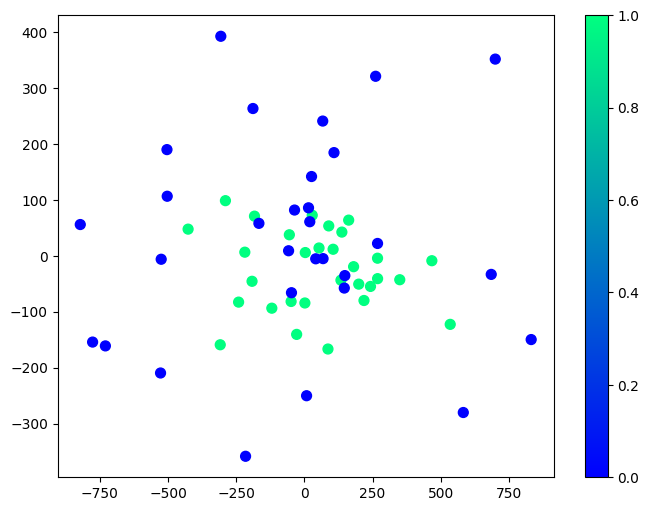

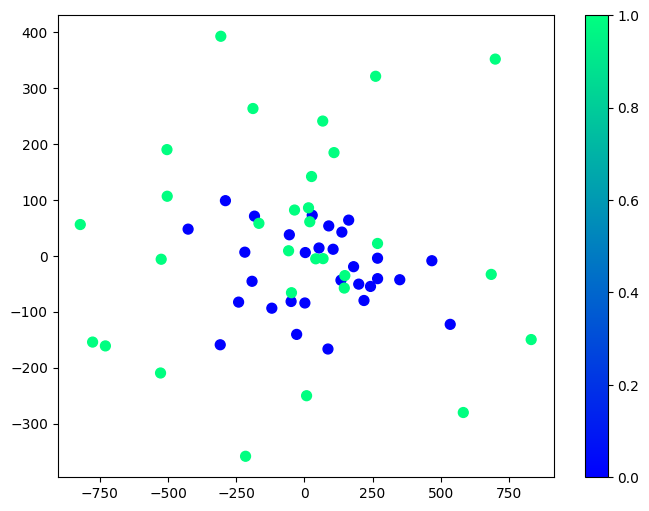

In [44]:
#PCA for visualization?


pca = PCA(n_components=2)
X_pca = pca.fit_transform(S)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=computed_labels_windows, cmap='winter', s=50)
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='winter', s=50)
plt.colorbar()
plt.show()

In [14]:
S.shape

(20, 2000)